In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import random as rd
from itertools import product
import seaborn as sns 


In [2]:
def output(t,th,e):
    return( (th*t*e)**(1/2) )

In [292]:
T = 1
k= 9/10
min_th = 0.5


In [293]:
grid = sorted(np.random.uniform(0,1,1000)) 
def f(th):
    return 1/len(grid)
def t_fb(th):
    return(T * 2 * th)

In [305]:
lambda_ = 1/2
grid = sorted(np.random.exponential(lambda_,1000)) 
def f(th):
    return lambda_ *np.exp(-lambda_ *th)

def t_fb(th):
    return( T *th)

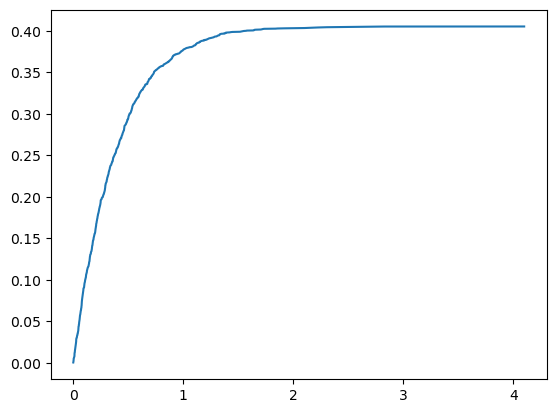

In [306]:
plt.plot(grid, np.cumsum([f(th)/len(grid) for th in grid]))

In [307]:

def optimal_t(th, k= k):
    return( th**(k/(1-k)) * T / (1-k))

In [308]:
optimal_t(5)

19531250.00000006

In [309]:
sum_test = sum([optimal_t(th)*f(th) for th in grid])

In [310]:
sum([T*th/(len(grid)) for th in grid])

0.4660549986605311

In [311]:
full_share = [output(T,th,1) for th in grid]
full_info = [output(t_fb(th),th,1) for th in grid]
no_ic = [output(t_fb(th),th,1-k) for th in grid]
no_ic_high_k = [output(t_fb(th),th,1-1/2) for th in grid]

#no_ic_w_itcp = [output(0.5+ (T-0.5)*th*f(th)/(len(grid))*2,th,1-k) for th in grid]

#full_share_above_min = [output(T/(1-min_th)*f(th)/len(grid), th,1-k) if th > min_th else 0 for th in grid]
share_above_min = [output(0.5*T*f(th)+ (T-0.5)/(1-min_th)*f(th)/len(grid), th,1-k) if th > min_th 
                   else output(0.5*T/len(grid), th, 1) for th in grid]

opt_t_gamma = [output(T*optimal_t(th),th,1-k) for th in grid]
#opt_t_gamma = [output(T*optimal_t(th, k =1/1000000)*f(th)/sum_test,th,1-1/1000000) for th in grid]

all_pay = [output(1, th, 1-k) if th ==0.99 else 0 for th in grid]


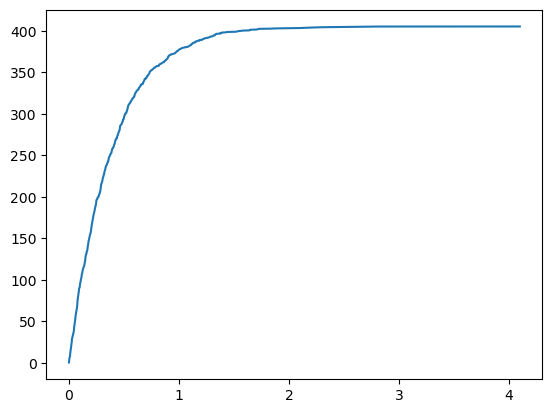

In [328]:
#plt.plot(grid, np.cumsum([T*optimal_t(th)*f(th)for th in grid]))
plt.plot(grid, np.cumsum([T*f(th) for th in grid]))

In [313]:
print(np.trapz([output(T,th,1)*f(th) for th in grid], grid), 
      np.trapz([output(t_fb(th),th,1)*f(th) for th in grid], grid), 
      np.trapz([output(t_fb(th) ,th,1-k)*f(th) for th in grid],grid), 
      np.trapz([output(t_fb(th),th,1-1/2)*f(th) for th in grid], grid),
      np.trapz([output(T*optimal_t(th),th,1-k)*f(th) for th in grid], grid)
     )

0.9408295822074023 1.2116292186983109 0.3831508010696937 0.856751236825334 74.12994044739715


In [314]:
np.trapz([t_fb(th)*f(th) for th in grid], grid)

1.2116292186983109

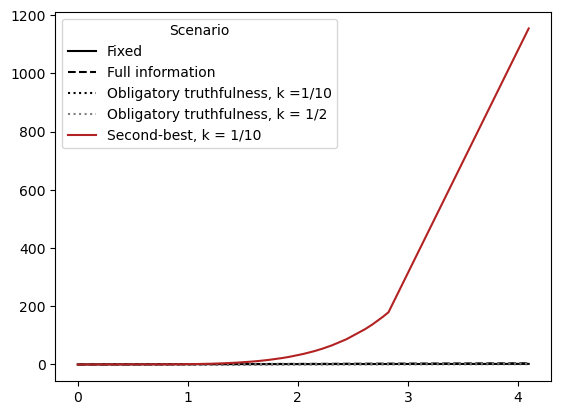

In [315]:
plt.plot(grid, full_share, color = 'black', label = 'Fixed')
plt.plot(grid, full_info, color = 'black', linestyle  = 'dashed', label = 'Full information')
plt.plot(grid, no_ic, color = 'black', linestyle  = 'dotted', label = 'Obligatory truthfulness, k =1/10')
plt.plot(grid, no_ic_high_k, color = 'grey', linestyle  = 'dotted', label = 'Obligatory truthfulness, k = 1/2')
plt.plot(grid, opt_t_gamma, color = 'firebrick', label = 'Second-best, k = 1/10')


plt.legend(title = 'Scenario')
#plt.plot(grid, no_ic_w_itcp)


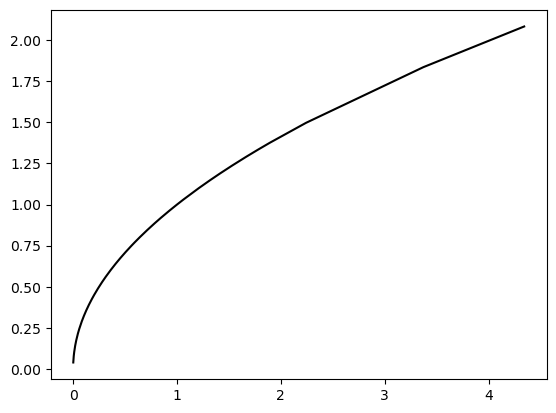

In [202]:
plt.plot(grid, full_share, color = 'black')
#plt.plot(grid, share_above_min, color ='grey')

#plt.plot(grid, all_pay)

In [225]:
(1-k)*0.5

0.25

In [150]:
len(grid)

101

In [274]:
np.sum( [0.5/len(grid) + (T-0.5)*th*f(th)/(len(grid))*2 for th in grid])

1.0

In [184]:
sum([(th-min_th)/(1-min_th)/51*2*(T-min_th)*f(th)if th > min_th else (T-min_th)/len([th for th in grid if th <= min_th]) for th in grid])

67.71399594320488

In [185]:
np.sum([th*f(th)/(101)*2 for th in grid])

0.9801980198019804

In [186]:
np.sum([output(1/len(grid),th,1) for th in grid])

66.14629471031478

In [187]:
sum([output(1/(1-min_th)/100, th, 1-k*th) if th > min_th else 0 for th in grid])

57.977004591545196

In [188]:
sum([output(1, th, 1-k*th) if th ==1 else 0 for th in grid])

0.7071067811865476

In [189]:
np.sum([output(th**2/29.55*T*f(th), th, 1-k*th) if th > min_th else 0 for th in grid])

(2.504003731881069e-12+40893.48428664419j)